Methods: ['mse']


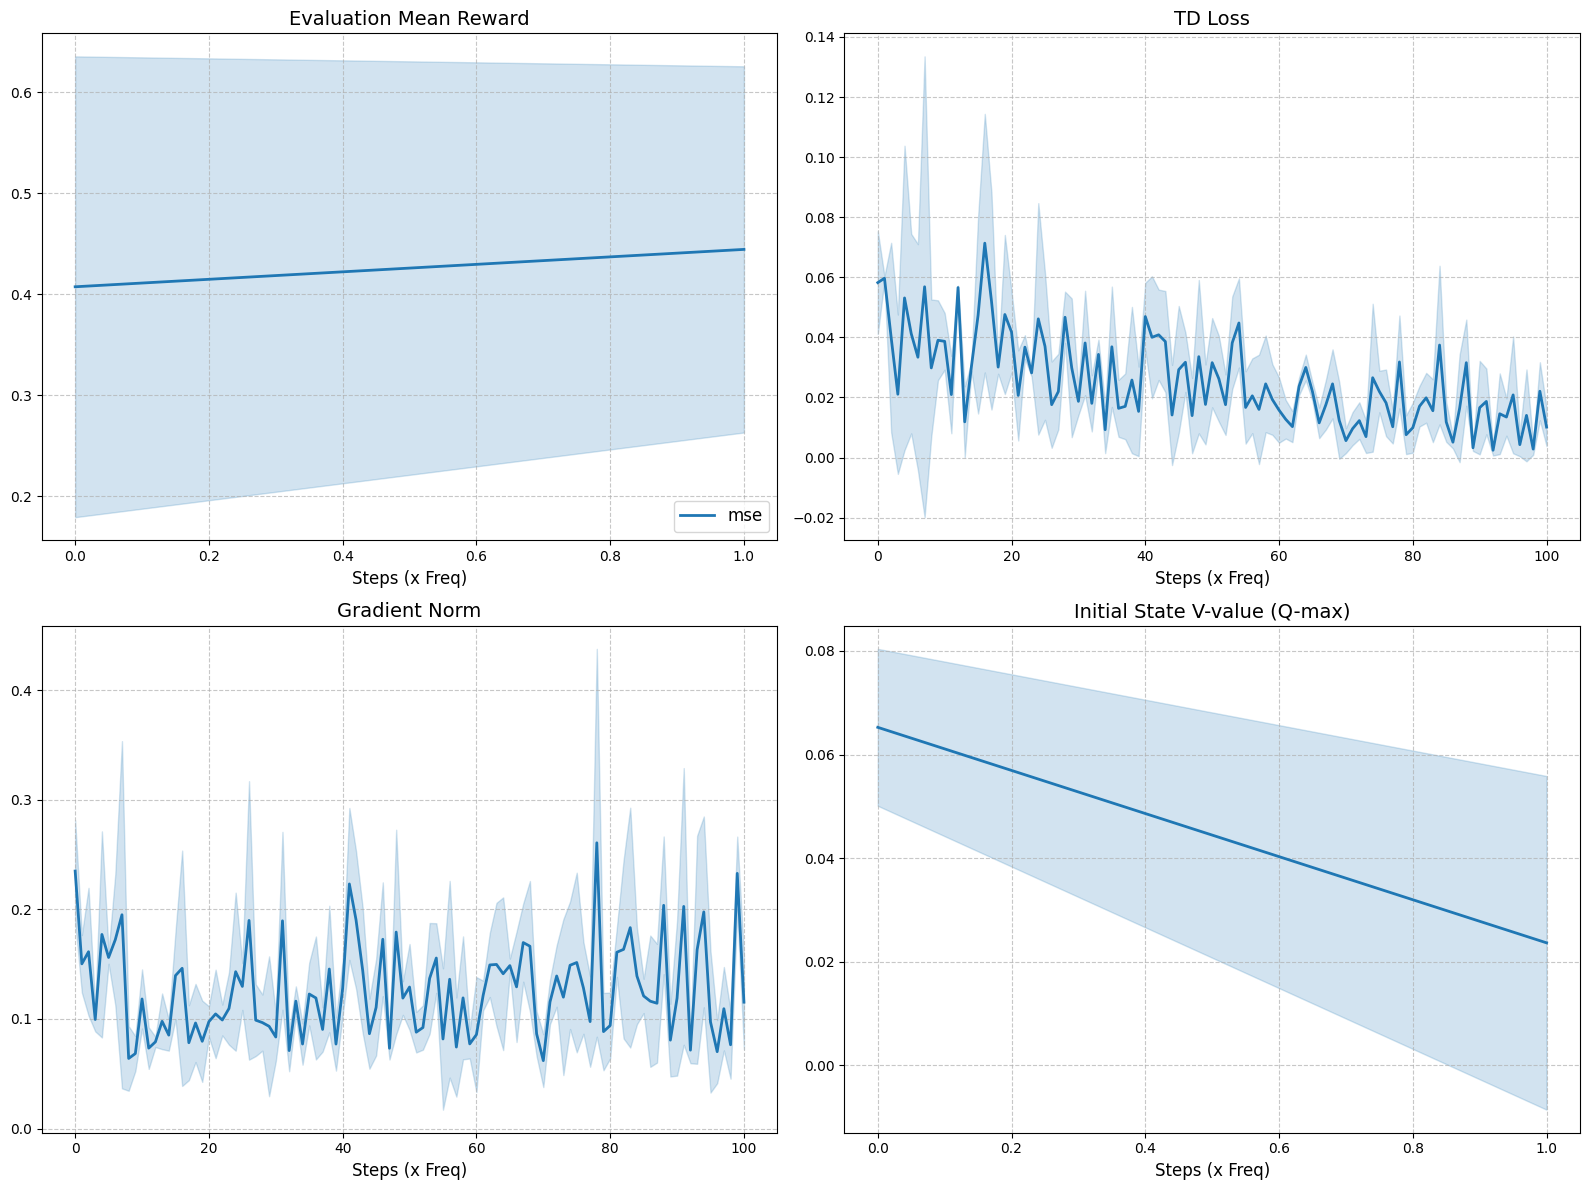

In [4]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


METRICS = [
    'mean_rw_history', 
    'td_loss_history', 
    'grad_norm_history', 
    'initial_state_v_history'
]

TITLES = [
    'Evaluation Mean Reward', 
    'TD Loss', 
    'Gradient Norm', 
    'Initial State V-value (Q-max)'
]


def load_and_plot_results(base_dir):
    data = {m: {} for m in METRICS}
    
    if not os.path.exists(base_dir):
        return

    methods = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    print(f"Methods: {methods}")

    for method in methods:
        method_path = os.path.join(base_dir, method)
        seed_files = [d for d in os.listdir(method_path) if d.startswith('seed')]
        
        for metric in METRICS:
            data[metric][method] = []
            
        for seed_file in seed_files:
            file_path = os.path.join(method_path, seed_file)
                
            with open(file_path, 'rb') as f:
                pkl_data = pickle.load(f)
            
            for metric in METRICS:
                if metric in pkl_data:
                    data[metric][method].append(pkl_data[metric])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for idx, metric in enumerate(METRICS):
        ax = axes[idx]
        
        for method_idx, method in enumerate(methods):
            lines = data[metric].get(method, [])
            if not lines:
                continue
                
            min_len = min(len(line) for line in lines)
            truncated_lines = np.array([line[:min_len] for line in lines])
            
            mean_line = np.mean(truncated_lines, axis=0)
            std_line = np.std(truncated_lines, axis=0)
            
            x = np.arange(len(mean_line))
            
            color = colors[method_idx % len(colors)]
            
            ax.plot(x, mean_line, label=method, color=color, linewidth=2)
            ax.fill_between(x, mean_line - std_line, mean_line + std_line, color=color, alpha=0.2)
            
        ax.set_title(TITLES[idx], fontsize=14)
        ax.set_xlabel("Steps (x Freq)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        if idx == 0:
            ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig('comparison_plot.png', dpi=300)
    plt.show()


load_and_plot_results(base_dir="metrics")